## Extracción de Caracteristicas para los sistemas trifasicos


In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.signal import hilbert, butter, lfilter, filtfilt
from scipy.fft import rfft, rfftfreq
from scipy.stats import skew, kurtosis, entropy
import pywt
from typing import List, Tuple, Dict, Any
import os
import glob
import nolds
from joblib import Parallel, delayed
import algoritmos_deteccion as ad
import random
import shutil

c:\Users\Juan_Saa\AppData\Local\Programs\Python\Python313\Lib\site-packages\nolds\datasets.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Segmentación para sistemas trifasicos

Buscando y cargando eficientemente la señal: Sag_A_clean_0010...
Procesando señal: Sag_A_clean_0010
Longitud original de la señal: 7200 muestras
Longitud de la señal segmentada: 794 muestras


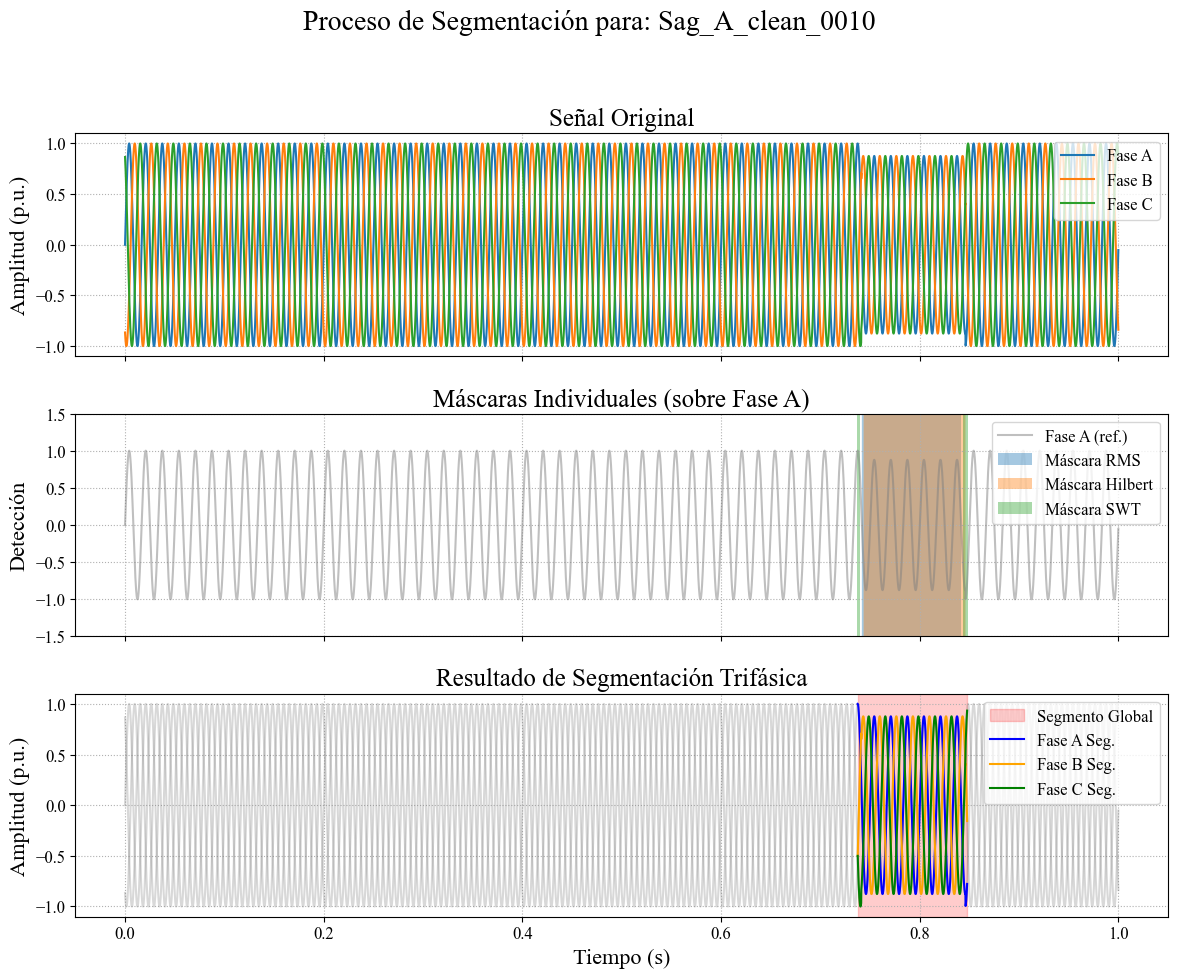

In [7]:
def _setup_academic_style():
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
    plt.rcParams['mathtext.fontset'] = 'stix'
    plt.rcParams['font.size'] = 14
    plt.rcParams['axes.labelsize'] = 16
    plt.rcParams['axes.titlesize'] = 18
    plt.rcParams['xtick.labelsize'] = 12
    plt.rcParams['ytick.labelsize'] = 12
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['lines.linewidth'] = 1.5
    

def visualizar_segmentacion_completa(va, vb, vc, fs, signal_id):
    """
    Genera un gráfico de 3 paneles para visualizar el proceso de segmentación.
    """
    _setup_academic_style()
    
    t = np.arange(len(va)) / fs

    # --- Generar máscaras para visualización (usando Fase A como referencia) ---
    mascara_rms = ad.generar_mascara_rms(va, fs)
    mascara_swt = ad.generar_mascara_swt(va)
    mascara_hilbert = ad.generar_mascara_hilbert(va)

    # --- Encontrar el segmento final trifásico ---
    t_inicio_idx, t_fin_idx = ad.encontrar_intervalo_global(va, vb, vc, fs)

    # --- Crear figura de 3 paneles ---
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    fig.suptitle(f'Proceso de Segmentación para: {signal_id}', fontsize=20)

    # Panel 1: Señal Trifásica Original
    axes[0].plot(t, va, label='Fase A')
    axes[0].plot(t, vb, label='Fase B')
    axes[0].plot(t, vc, label='Fase C')
    axes[0].set_ylabel('Amplitud (p.u.)')
    axes[0].set_title('Señal Original')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, linestyle=':')

    # Panel 2: Máscaras de Detección (sobre Fase A)
    axes[1].plot(t, va, color='gray', alpha=0.5, label='Fase A (ref.)')
    axes[1].fill_between(t, -1.5, 1.5, where=mascara_rms, alpha=0.4, label='Máscara RMS', step='post')
    axes[1].fill_between(t, -1.5, 1.5, where=mascara_hilbert, alpha=0.4, label='Máscara Hilbert', step='post')
    axes[1].fill_between(t, -1.5, 1.5, where=mascara_swt, alpha=0.4, label='Máscara SWT', step='post')
    axes[1].set_ylabel('Detección')
    axes[1].set_title('Máscaras Individuales (sobre Fase A)')
    axes[1].set_ylim(-1.5, 1.5)
    axes[1].legend(loc='upper right')
    axes[1].grid(True, linestyle=':')

    # Panel 3: Resultado de la Segmentación
    axes[2].plot(t, va, color='gray', alpha=0.3)
    axes[2].plot(t, vb, color='gray', alpha=0.3)
    axes[2].plot(t, vc, color='gray', alpha=0.3)
    if t_inicio_idx is not None and t_fin_idx is not None:
        axes[2].axvspan(t[t_inicio_idx], t[t_fin_idx], color='red', alpha=0.2, label='Segmento Global')
        t_segmento = t[t_inicio_idx:t_fin_idx]
        axes[2].plot(t_segmento, va[t_inicio_idx:t_fin_idx], color='blue', label='Fase A Seg.')
        axes[2].plot(t_segmento, vb[t_inicio_idx:t_fin_idx], color='orange', label='Fase B Seg.')
        axes[2].plot(t_segmento, vc[t_inicio_idx:t_fin_idx], color='green', label='Fase C Seg.')
    axes[2].set_xlabel('Tiempo (s)')
    axes[2].set_ylabel('Amplitud (p.u.)')
    axes[2].set_title('Resultado de Segmentación Trifásica')
    axes[2].legend(loc='upper right')
    axes[2].grid(True, linestyle=':')
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# ==============================================================================
file_path = r"C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Generacion_Señales\Trifasico\Dataset_Trifasico_Completo_2.parquet"
signal_id_prueba = "Sag_A_clean_0010"
fs = 7200 # frecuencia de muestreo

print(f"Buscando y cargando eficientemente la señal: {signal_id_prueba}...")

# 2. Carga SOLO la señal necesaria usando filtros (evita error de memoria)
try:
    filters = [('signal_id', '=', signal_id_prueba)]
    una_señal_df = pd.read_parquet(file_path, filters=filters)
except Exception as e:
    print(f"No se pudo cargar la señal. Error: {e}")
    # Salir si el DataFrame no se pudo crear
    exit()

# 3. El resto de tu código funciona igual
va_original = una_señal_df['Phase_A'].values
vb_original = una_señal_df['Phase_B'].values
vc_original = una_señal_df['Phase_C'].values

print(f"Procesando señal: {signal_id_prueba}")
print(f"Longitud original de la señal: {len(va_original)} muestras")

# Llama a la nueva función orquestadora
# (Asegúrate de que 'ad' esté importado si tus funciones están en otro archivo)
va_seg, vb_seg, vc_seg = ad.segmentar_evento_trifasico(va_original, vb_original, vc_original, fs)

print(f"Longitud de la señal segmentada: {len(va_seg)} muestras")

visualizar_segmentacion_completa(va_original, vb_original, vc_original, fs, signal_id_prueba)

## Caracteristicas

In [7]:
import numpy as np
import pywt
from scipy.stats import kurtosis
import pandas as pd
import random


# =============================================================================
# SECCIÓN 1: FUNCIONES DE TRANSFORMACIÓN TRIFÁSICA (Sin cambios)
# =============================================================================

def calcular_transformaciones_trifasicas(va, vb, vc):
    """
    Calcula las Componentes Simétricas (V1, V2) y la Transformada de Clarke (alpha, beta).
    """
    a = np.exp(1j * 2 * np.pi / 3)
    va_c, vb_c, vc_c = va.astype(complex), vb.astype(complex), vc.astype(complex)
    v1 = (1/3) * (va_c + a * vb_c + a**2 * vc_c)
    v2 = (1/3) * (va_c + a**2 * vb_c + a * vc_c)
    v_alpha = (2/3) * (va - 0.5 * vb - 0.5 * vc)
    v_beta = (2/3) * (np.sqrt(3)/2 * vb - np.sqrt(3)/2 * vc)
    return v1, v2, v_alpha, v_beta

# =============================================================================
# SECCIÓN 2: FUNCIÓN DE EXTRACCIÓN DE CARACTERÍSTICAS (MODIFICADA)
# =============================================================================

def extraer_caracteristicas_elite(va_seg, vb_seg, vc_seg, fs, rms_nominal_val):
    """
    Extrae el "Top 10" de características Y AÑADE las 2 características avanzadas.
    """
    v1, v2, v_alpha, v_beta = calcular_transformaciones_trifasicas(va_seg, vb_seg, vc_seg)
    v1_mag, v2_mag, v2_fase = np.abs(v1), np.abs(v2), np.angle(v2)
    clarke_mag = np.sqrt(v_alpha**2 + v_beta**2)
    vmin_mag = np.minimum.reduce([np.abs(va_seg), np.abs(vb_seg), np.abs(vc_seg)])
    
    features = {}
    features['rms_V1mag'] = np.sqrt(np.mean(v1_mag**2))
    features['profundidad_V1mag'] = features['rms_V1mag'] / rms_nominal_val if rms_nominal_val > 1e-6 else 0.0
    features['rms_V2mag'] = np.sqrt(np.mean(v2_mag**2))
    features['vuf'] = features['rms_V2mag'] / features['rms_V1mag'] if features['rms_V1mag'] > 1e-6 else 0.0
    
    # --- INICIO DE LA CORRECCIÓN ---
    # Verificamos si la señal v2_mag es constante para evitar división por cero.
    if np.std(v2_mag) < 1e-9:
        features['curtosis_V2mag'] = 0.0
    else:
        features['curtosis_V2mag'] = kurtosis(v2_mag) if len(v2_mag) >= 4 else 0.0
    # --- FIN DE LA CORRECCIÓN ---
    
    features['media_V2fase'] = np.mean(v2_fase)
    features['std_V2fase'] = np.std(v2_fase)
    features['rms_ClarkeMag'] = np.sqrt(np.mean(clarke_mag**2))
    features['rms_Vmin'] = np.sqrt(np.mean(vmin_mag**2))
    
    if pywt.dwt_max_level(len(v2_mag), 'db4') > 0:
        coeffs = pywt.wavedec(v2_mag, 'db4', level=1)
        features['wavelet_energia_cD1_V2mag'] = np.sum(coeffs[-1]**2)
    else:
        features['wavelet_energia_cD1_V2mag'] = 0.0

    # (El resto de tu código para las características avanzadas está perfecto y no cambia)
    rms_a = np.sqrt(np.mean(va_seg**2))
    rms_b = np.sqrt(np.mean(vb_seg**2))
    rms_c = np.sqrt(np.mean(vc_seg**2))
    
    fases_rms = [rms_a, rms_b, rms_c]
    if np.all(np.isclose(fases_rms, rms_nominal_val, atol=0.05)):
        features['fase_mas_afectada'] = 'N'
    else:
        idx_min_rms = np.argmin(fases_rms)
        features['fase_mas_afectada'] = ['A', 'B', 'C'][idx_min_rms]

    if rms_nominal_val > 1e-6:
        profundidad_b = 1 - (rms_b / rms_nominal_val)
        profundidad_c = 1 - (rms_c / rms_nominal_val)
        features['diferencia_profundidad_BC'] = np.abs(profundidad_b - profundidad_c)
    else:
        features['diferencia_profundidad_BC'] = 0.0
        
    return features

def procesar_una_señal(signal_df):
    """
    Versión corregida que encuentra dinámicamente el segmento del evento
    o toma una muestra aleatoria si no lo encuentra (caso 'Normal').
    """
    etiqueta = signal_df['etiqueta'].iloc[0]
    va_orig, vb_orig, vc_orig = signal_df['Phase_A'].values, signal_df['Phase_B'].values, signal_df['Phase_C'].values
    fs = 7200
    
    # --- LÓGICA DE SEGMENTACIÓN CORRECTA ---
    
    # 1. Calcular el valor RMS nominal de la parte pre-falla
    muestras_ciclo = int(fs / 60) # Asumiendo 60 Hz
    rms_nominal_val = np.sqrt(np.mean(va_orig[:5*muestras_ciclo]**2))
    
    # 2. Intentar encontrar el inicio y fin del evento
    # Asegúrate de tener tu módulo 'ad' importado
    t_inicio, t_fin = ad.encontrar_intervalo_global(va_orig, vb_orig, vc_orig, fs)
    
    # 3. Cortar el segmento basado en si se encontró un evento o no
    if t_inicio is not None and t_fin is not None:
        # Si se encontró un evento (caso SAG), se usa ese segmento
        va_seg, vb_seg, vc_seg = va_orig[t_inicio:t_fin], vb_orig[t_inicio:t_fin], vc_orig[t_inicio:t_fin]
    else:
        # Si NO se encontró evento (caso NORMAL), se toma un segmento aleatorio
        longitud_segmento = 15 * muestras_ciclo
        if len(va_orig) > longitud_segmento:
            inicio_aleatorio = random.randint(0, len(va_orig) - longitud_segmento)
            fin_aleatorio = inicio_aleatorio + longitud_segmento
            va_seg = va_orig[inicio_aleatorio:fin_aleatorio]
            vb_seg = vb_orig[inicio_aleatorio:fin_aleatorio]
            vc_seg = vc_orig[inicio_aleatorio:fin_aleatorio]
        else:
            va_seg, vb_seg, vc_seg = va_orig, vb_orig, vc_orig

    # Si por alguna razón el segmento es vacío, usamos la señal original para evitar errores
    if len(va_seg) == 0:
        va_seg, vb_seg, vc_seg = va_orig, vb_orig, vc_orig
            
    # La llamada a la extracción de características ahora recibe el segmento correcto
    fila_final = extraer_caracteristicas_elite(va_seg, vb_seg, vc_seg, fs, rms_nominal_val)
    fila_final['etiqueta'] = etiqueta
        
    result_series = pd.Series(fila_final)
    result_series.name = signal_df.name
    return result_series

In [8]:
import pandas as pd
import numpy as np
import dask.dataframe as dd
from dask.diagnostics import ProgressBar
import time
import os
import glob
import shutil # <--- IMPORTACIÓN NECESARIA

if __name__ == '__main__':
    start_time = time.time()

    # Rutas de entrada y salida
    input_path = r"C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Generacion_Señales\Trifasico\Dataset_Trifasico_Bollen_Completo.parquet"
    output_path = "Dataset_Caracteristicas_Trifasico_2.parquet"
    temp_dir = "temp_caracteristicas"

    if not os.path.exists(temp_dir):
        os.makedirs(temp_dir)

    print("Obteniendo la lista de clases del dataset...")
    clases_de_fallas = pd.read_parquet(input_path, columns=['etiqueta'])['etiqueta'].unique()
    print(f"Clases encontradas: {clases_de_fallas}")


    meta = {
        # Características Elite
        'rms_V1mag': 'float64', 'profundidad_V1mag': 'float64',
        'rms_V2mag': 'float64', 'vuf': 'float64', 'curtosis_V2mag': 'float64',
        'media_V2fase': 'float64', 'std_V2fase': 'float64',
        'rms_ClarkeMag': 'float64',
        'rms_Vmin': 'float64',
        'wavelet_energia_cD1_V2mag': 'float64',
        
        # <<< TUS NUEVAS CARACTERÍSTICAS DEBEN ESTAR AQUÍ >>>
        'fase_mas_afectada': 'object',
        'diferencia_profundidad_BC': 'float64',
        
        # Etiqueta al final
        'etiqueta': 'object'
    }

    # Procesar una clase a la vez para controlar el uso de memoria
    for clase in clases_de_fallas:
            print(f"\n--- Iniciando procesamiento para la clase: {clase} ---")
            ddf_clase = dd.read_parquet(input_path, filters=[('etiqueta', '=', clase)])
            
            # Asumo que esta función existe en tu entorno
            # from tu_libreria import procesar_una_señal_definitivo 

            with ProgressBar():
                caracteristicas_df = ddf_clase.groupby('signal_id').apply(
                    procesar_una_señal, meta=meta
                ).compute(scheduler='threads')
            
            temp_file_path = os.path.join(temp_dir, f"caracteristicas_{clase}.parquet")
            caracteristicas_df.to_parquet(temp_file_path, index=True)
            print(f"Características para la clase '{clase}' guardadas en: {temp_file_path}")

    # Unir todos los archivos temporales en el dataset final
    print("\n--- Uniendo todos los archivos de características ---")
    ddf_final = dd.read_parquet(os.path.join(temp_dir, "*.parquet"))
    
    with ProgressBar():
        ddf_final.index.name = 'signal_id' # Asegurar que el índice tenga nombre
        ddf_final.to_parquet(output_path, write_index=True)

    print(f"\nProcesamiento completado.")
    end_time = time.time()
    print(f"¡Proceso completo en {(end_time - start_time) / 60:.2f} minutos!")
    print(f"Dataset de características final guardado en: {output_path}")

    # Limpiar el directorio temporal
    print("Limpiando directorio temporal...")
    shutil.rmtree(temp_dir)
    print("Directorio temporal eliminado.")

Obteniendo la lista de clases del dataset...
Clases encontradas: ['Normal' 'Sag_A' 'Sag_B' 'Sag_C' 'Sag_D' 'Sag_E' 'Sag_F' 'Sag_G']

--- Iniciando procesamiento para la clase: Normal ---
[########################################] | 100% Completed | 40.34 s
Características para la clase 'Normal' guardadas en: temp_caracteristicas\caracteristicas_Normal.parquet

--- Iniciando procesamiento para la clase: Sag_A ---
[########################################] | 100% Completed | 42.32 s
Características para la clase 'Sag_A' guardadas en: temp_caracteristicas\caracteristicas_Sag_A.parquet

--- Iniciando procesamiento para la clase: Sag_B ---
[########################################] | 100% Completed | 38.94 s
Características para la clase 'Sag_B' guardadas en: temp_caracteristicas\caracteristicas_Sag_B.parquet

--- Iniciando procesamiento para la clase: Sag_C ---
[########################################] | 100% Completed | 40.26 s
Características para la clase 'Sag_C' guardadas en: temp_car

In [9]:
import pandas as pd

# Simplemente apuntas a la CARPETA principal
path_a_la_carpeta = r"C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Caracteristicas\Dataset_Caracteristicas_Trifasico_2.parquet"

print(f"Cargando dataset particionado desde: {path_a_la_carpeta}")

# Pandas leerá todos los archivos 'part.*.parquet' dentro de la carpeta
# y los unirá automáticamente en un solo DataFrame.
df_caracteristicas = pd.read_parquet(path_a_la_carpeta)

print("\n¡Dataset cargado con éxito!")
print("-" * 50)

# Ahora puedes inspeccionarlo como siempre
print(df_caracteristicas.info())

print("\nPrimeras 5 filas:")
print(df_caracteristicas.head())

print("\nConteo por clase:")
print(df_caracteristicas['etiqueta'].value_counts())

Cargando dataset particionado desde: C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Caracteristicas\Dataset_Caracteristicas_Trifasico_2.parquet

¡Dataset cargado con éxito!
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 32800 entries, Normal_clean_0002 to Sag_G_noisy_1099
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   rms_V1mag                  32800 non-null  float64
 1   profundidad_V1mag          32800 non-null  float64
 2   rms_V2mag                  32800 non-null  float64
 3   vuf                        32800 non-null  float64
 4   curtosis_V2mag             32800 non-null  float64
 5   media_V2fase               32800 non-null  float64
 6   std_V2fase                 32800 non-null  float64
 7   rms_ClarkeMag              32800 non-null  float64
 8   rms_Vmin                   32800 non-null  float64
 9   wavel

Cargando el dataset de características...
Dataset cargado. Columnas de características: ['rms_V1mag', 'profundidad_V1mag', 'rms_V2mag', 'vuf', 'curtosis_V2mag', 'media_V2fase', 'std_V2fase', 'rms_ClarkeMag', 'rms_Vmin', 'wavelet_energia_cD1_V2mag', 'fase_mas_afectada', 'diferencia_profundidad_BC']

Preprocesando características...
Se escalaron 11 características numéricas.
Se codificaron 4 características categóricas.
Dimensiones de la matriz final para t-SNE: (32800, 15)

Calculando la proyección t-SNE... (esto puede tardar unos minutos)
Generando el gráfico...


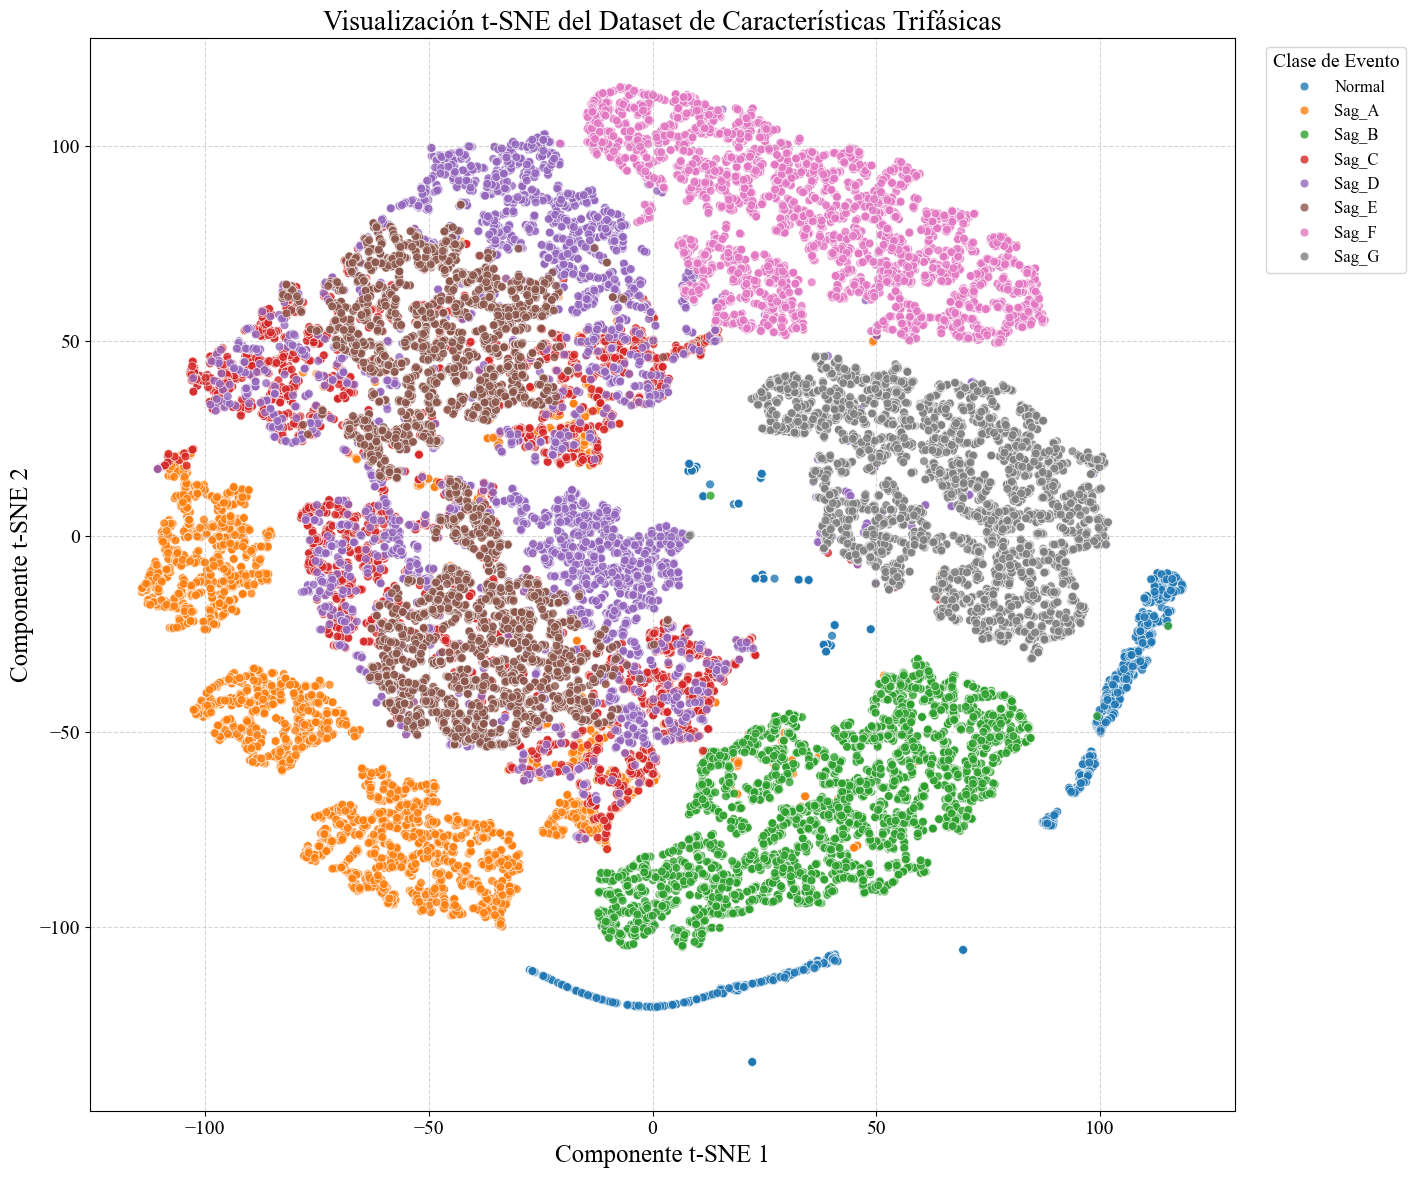

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

def _setup_academic_style():
    """Configura los parámetros de Matplotlib para un estilo tipo IEEE."""
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
    plt.rcParams['mathtext.fontset'] = 'stix'
    plt.rcParams['font.size'] = 14
    plt.rcParams['axes.labelsize'] = 18
    plt.rcParams['axes.titlesize'] = 20
    plt.rcParams['xtick.labelsize'] = 14
    plt.rcParams['ytick.labelsize'] = 14
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['lines.linewidth'] = 1.5

# --- 1. Cargar y preparar los datos ---
print("Cargando el dataset de características...")
data_path = r"C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Caracteristicas\Dataset_Caracteristicas_Trifasico_2.parquet"
df = pd.read_parquet(data_path)

X = df.drop('etiqueta', axis=1)
y = df['etiqueta']
print("Dataset cargado. Columnas de características:", X.columns.tolist())

# --- 2. Separar características numéricas y categóricas ---
X_numericas = X.select_dtypes(include=np.number)
X_categoricas = X.select_dtypes(exclude=np.number)

# --- 3. Escalar las numéricas y codificar las categóricas ---
print("\nPreprocesando características...")
scaler = StandardScaler()
X_numericas_scaled = scaler.fit_transform(X_numericas)
print(f"Se escalaron {X_numericas_scaled.shape[1]} características numéricas.")

X_categoricas_encoded = pd.get_dummies(X_categoricas)
print(f"Se codificaron {X_categoricas_encoded.shape[1]} características categóricas.")

# --- 4. Unir todo en una matriz final ---
X_final_para_tsne = np.hstack([X_numericas_scaled, X_categoricas_encoded.values])
print(f"Dimensiones de la matriz final para t-SNE: {X_final_para_tsne.shape}")

# --- 5. Cálculo de t-SNE ---
# --- CORRECCIÓN ---
# Ahora usamos la variable correcta 'X_final_para_tsne' que ya está procesada.
print("\nCalculando la proyección t-SNE... (esto puede tardar unos minutos)")
tsne = TSNE(n_components=2, random_state=42, perplexity=20, max_iter=1000, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_final_para_tsne) # <<< USAR LA VARIABLE CORRECTA

# Crear un DataFrame para la visualización
tsne_df = pd.DataFrame(data=X_tsne, columns=['Componente 1', 'Componente 2'])
tsne_df['etiqueta'] = y.values # Usar .values para evitar problemas de índice

# --- 6. Graficar ---
print("Generando el gráfico...")
_setup_academic_style()
plt.figure(figsize=(16, 12))

ax = sns.scatterplot(
    x="Componente 1", y="Componente 2",
    hue="etiqueta",
    palette=sns.color_palette("tab10", len(df['etiqueta'].unique())),
    data=tsne_df,
    legend="full",
    alpha=0.8,
    s=40
)

plt.title('Visualización t-SNE del Dataset de Características Trifásicas')
plt.xlabel('Componente t-SNE 1')
plt.ylabel('Componente t-SNE 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Clase de Evento', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.savefig("tsne_caracteristicas_trifasicas.svg", format='svg', dpi=300)
plt.show()